<a href="https://colab.research.google.com/github/Capaquira/projectsLivreLow-code/blob/Notebooks/FraudeBancario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

In [48]:
Source = pd.read_csv('https://oreil.ly/n1y1X?raw=true',on_bad_lines = 'skip',engine='python')
Source.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [49]:
Source

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [50]:
Source.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [51]:
Source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [52]:
Source.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


**Descripcion of category columns (no numeric)**

In [53]:
cols = ['type', 'nameOrig','nameDest']
Source[cols].describe()

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C1530544995,C1286084959
freq,2237500,3,113


In [54]:
Source['isCorrect'] = (
    Source['isFraud'] == Source['isFlaggedFraud']
)

In [55]:
Source['isCorrect'].sum()

np.int64(6354423)

In [56]:
# Transacciones fraudulentas correctas
(Source['isFraud'] * Source['isCorrect']).sum()

np.int64(16)

In [57]:
# Transacciones fraudulentas
Source['isFraud'].sum()

np.int64(8213)

In [58]:
# Porcentaje de deteccion correcto
RateSuccess = (Source['isFraud'] * Source['isCorrect']).sum()*100/Source['isFraud'].sum()
print(round(RateSuccess,2))

0.19


<Axes: ylabel='type'>

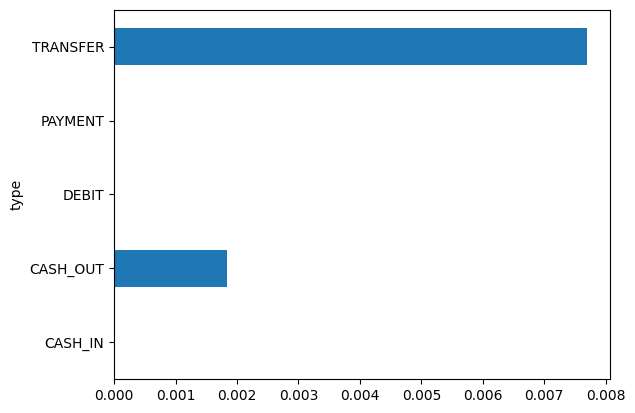

In [59]:
 # Transactions fraudulenses par valeur
Source.groupby('type')['isFraud'].mean().plot.barh()

In [60]:
Source.groupby('type')['isFraud'].value_counts()

type      isFraud
CASH_IN   0          1399284
CASH_OUT  0          2233384
          1             4116
DEBIT     0            41432
PAYMENT   0          2151495
TRANSFER  0           528812
          1             4097
Name: count, dtype: int64

/tmp/ipython-input-1718062889.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Source.groupby('amountBkts')['isFraud'].mean().plot.bar()


<Axes: xlabel='amountBkts'>

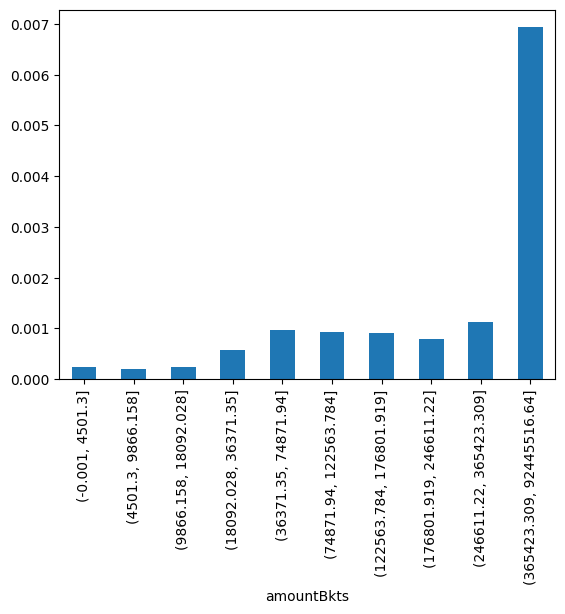

In [61]:
Source['amountBkts'] = pd.qcut(Source['amount'],10)
Source.groupby('amountBkts')['isFraud'].mean().plot.bar()

/tmp/ipython-input-1414915186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Source.groupby('oldbalanceOrgBkts')['isFraud'].mean().plot.bar()


<Axes: xlabel='oldbalanceOrgBkts'>

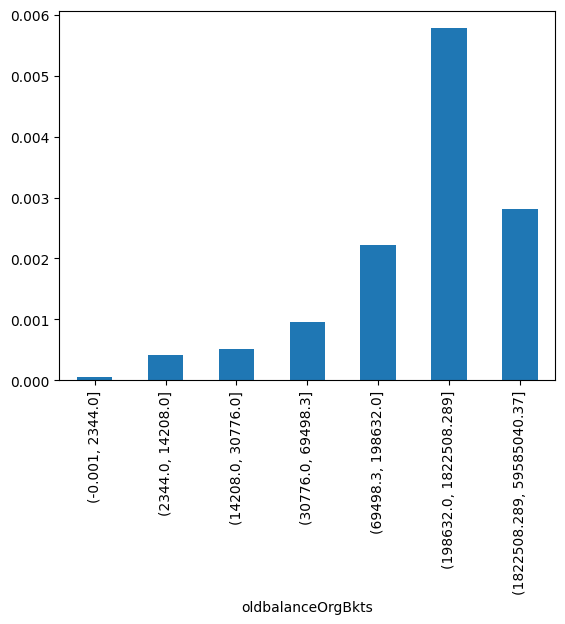

In [62]:
Source['oldbalanceOrgBkts'] = pd.qcut(Source['oldbalanceOrg'],10, duplicates ='drop')
Source.groupby('oldbalanceOrgBkts')['isFraud'].mean().plot.bar()
# La tendance generale est que plus l'ancien solde du comte emetteur est eleve; plus le risque de fraude est eleve:

/tmp/ipython-input-4090904756.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Source.groupby('oldbalanceDestBkts')['isFraud'].mean().plot.bar()


<Axes: xlabel='oldbalanceDestBkts'>

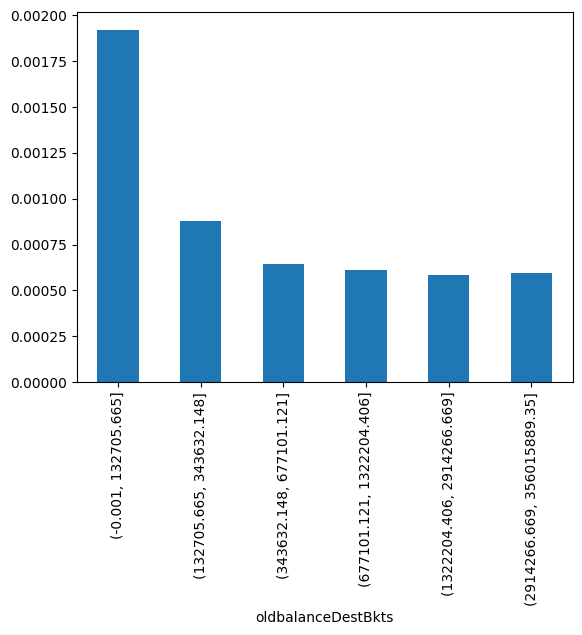

In [63]:
Source['oldbalanceDestBkts'] = pd.qcut(Source['oldbalanceDest'],10, duplicates ='drop')
Source.groupby('oldbalanceDestBkts')['isFraud'].mean().plot.bar()
# El saldo de la cuenta destino antes de transaccion no esta cero

/tmp/ipython-input-3991216985.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Source.groupby('newbalanceOrigBkts')['isFraud'].mean().plot.bar()


<Axes: xlabel='newbalanceOrigBkts'>

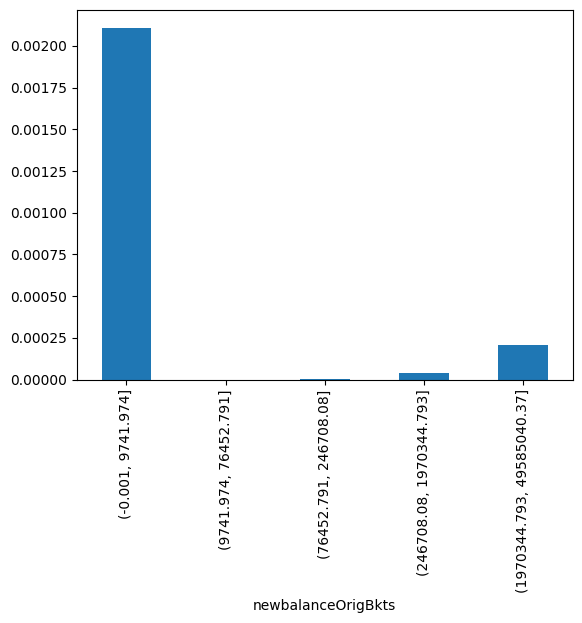

In [64]:
Source['newbalanceOrigBkts'] = pd.qcut(Source['newbalanceOrig'],10, duplicates ='drop')
Source.groupby('newbalanceOrigBkts')['isFraud'].mean().plot.bar()
# La cuenta de origen despues de la transaccion queda casi en zero

/tmp/ipython-input-246943049.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Source.groupby('newbalanceDestBkts')['isFraud'].mean().plot.bar()


<Axes: xlabel='newbalanceDestBkts'>

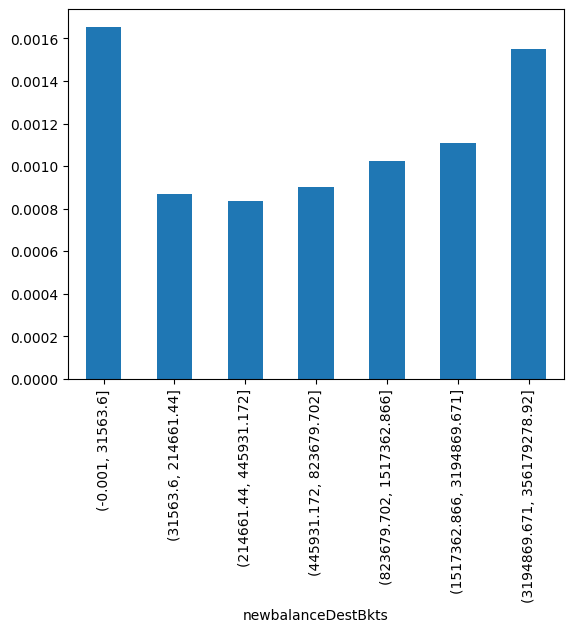

In [65]:
Source['newbalanceDestBkts'] = pd.qcut(Source['newbalanceDest'],10, duplicates ='drop')
Source.groupby('newbalanceDestBkts')['isFraud'].mean().plot.bar()
# La cuenta destino despues de la transaccion: (1) Incrementa Drasticamente; (2) No incrementa considerable porque el; presumiblemente por un bajo monto enviado

In [66]:
Cashout_df = Source.query("type == 'CASH_OUT' & newbalanceDest < 1e8")
Cashout_df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,isCorrect,amountBkts,oldbalanceOrgBkts,oldbalanceDestBkts,newbalanceOrigBkts,newbalanceDestBkts
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,False,"(-0.001, 4501.3]","(-0.001, 2344.0]","(-0.001, 132705.665]","(-0.001, 9741.974]","(-0.001, 31563.6]"
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,True,"(176801.919, 246611.22]","(14208.0, 30776.0]","(-0.001, 132705.665]","(-0.001, 9741.974]","(31563.6, 214661.44]"
42,1,CASH_OUT,110414.71,C768216420,26845.41,0.0,C1509514333,288800.00,2415.16,0,0,True,"(74871.94, 122563.784]","(14208.0, 30776.0]","(132705.665, 343632.148]","(-0.001, 9741.974]","(-0.001, 31563.6]"
47,1,CASH_OUT,56953.90,C1570470538,1942.02,0.0,C824009085,70253.00,64106.18,0,0,True,"(36371.35, 74871.94]","(-0.001, 2344.0]","(-0.001, 132705.665]","(-0.001, 9741.974]","(31563.6, 214661.44]"
48,1,CASH_OUT,5346.89,C512549200,0.00,0.0,C248609774,652637.00,6453430.91,0,0,True,"(4501.3, 9866.158]","(-0.001, 2344.0]","(343632.148, 677101.121]","(-0.001, 9741.974]","(3194869.671, 356179278.92]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.0,C1662241365,276433.18,339850.17,1,0,False,"(36371.35, 74871.94]","(30776.0, 69498.3]","(132705.665, 343632.148]","(-0.001, 9741.974]","(214661.44, 445931.172]"
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0,False,"(365423.309, 92445516.64]","(198632.0, 1822508.289]","(343632.148, 677101.121]","(-0.001, 9741.974]","(1517362.866, 3194869.671]"
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,False,"(246611.22, 365423.309]","(198632.0, 1822508.289]","(-0.001, 132705.665]","(-0.001, 9741.974]","(214661.44, 445931.172]"
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,False,"(365423.309, 92445516.64]","(1822508.289, 59585040.37]","(-0.001, 132705.665]","(-0.001, 9741.974]","(3194869.671, 356179278.92]"


<Axes: xlabel='oldbalanceDest', ylabel='newbalanceDest'>

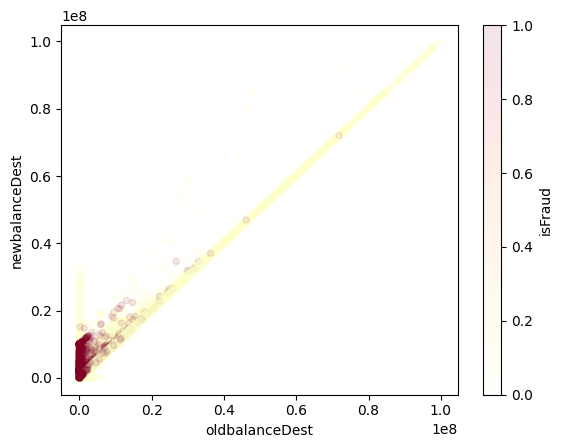

In [67]:

Cashout_df.plot.scatter(x = 'oldbalanceDest', y = 'newbalanceDest',
                        c = 'isFraud',
                        colormap = 'YlOrRd',
                        alpha = 0.1
                        )

# cmap = 'viridis'
# cmap = 'coolwarm'
# Otras opcciones de colormaps: YlOrRd, YlOrBr, Inferno, Plasma, Reds

# Como hay relacion entre dos caracteriticas es mejor llevar acabo un cruzamiento de caracteristicas
# Ciudad_Dispositivo = Ciudad + "_" + Dispositivo, Eso permite al modelo detectar patrones como: “Los usuarios de Madrid en móvil compran más.”

**Nota:** Un cruzamiento de características (feature crossing) en Machine Learning es una técnica donde combinamos dos o más variables para crear una nueva característica que capture relaciones que el modelo no podría aprender fácilmente por separado.

In [68]:
Source.to_csv('transactions.csv',
                      encoding = 'utf-8',
                      index =False)

In [69]:
!head transactions.csv

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,isCorrect,amountBkts,oldbalanceOrgBkts,oldbalanceDestBkts,newbalanceOrigBkts,newbalanceDestBkts
1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,True,"(4501.3, 9866.158]","(69498.3, 198632.0]","(-0.001, 132705.665]","(76452.791, 246708.08]","(-0.001, 31563.6]"
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,True,"(-0.001, 4501.3]","(14208.0, 30776.0]","(-0.001, 132705.665]","(9741.974, 76452.791]","(-0.001, 31563.6]"
1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,False,"(-0.001, 4501.3]","(-0.001, 2344.0]","(-0.001, 132705.665]","(-0.001, 9741.974]","(-0.001, 31563.6]"
1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,False,"(-0.001, 4501.3]","(-0.001, 2344.0]","(-0.001, 132705.665]","(-0.001, 9741.974]","(-0.001, 31563.6]"
1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,T

In [70]:
from google.colab import files

In [ ]:
files.download('transactions.cvs')